In [1]:
# Imports
import pandas as pd
import os
from dotenv import load_dotenv

from src.texas_county_dashboards.scripts.census_client import CensusClient
from src.texas_county_dashboards.analytics.county_analytics import CountyAnalytics

In [2]:
# Retrieve the api key
load_dotenv()
api_key = os.getenv("CENSUS_API_KEY")

census_client = CensusClient(
    api_key=api_key
)

analytics = CountyAnalytics(census_client=census_client)

df = analytics.load_data()

In [3]:
df = analytics.calculate_metrics()

In [4]:
df.columns

Index(['state', 'county', 'NAME', 'population', 'population_25_plus',
       'less_than_9th_grade', 'high_school_graduate', 'bachelors', 'masters',
       'professional', 'doctorate', 'population_16_plus', 'labor_force',
       'employed', 'unemployed', 'total_population', 'median_age',
       'male_population', 'female_population', 'white_population',
       'black_population', 'american_indian_population', 'asian_population',
       'native_hawaiian_population', 'other_race_population',
       'two_or_more_races_population', 'hispanic_population',
       'median_household_income', 'per_capita_income', 'poverty_universe',
       'population_below_poverty', 'households_with_snap', 'housing_units',
       'occupied_housing_units', 'vacant_housing_units',
       'owner_occupied_units', 'renter_occupied_units', 'median_home_value',
       'median_gross_rent', 'average_household_size', 'bachelors_plus_pct',
       'unemployment_rate', 'poverty_rate', 'homeownership_rate',
       'vacancy_r

## Population

In [5]:
# What counties have the higher population?
df.nlargest(
    10,
    "population",
)[
    ["NAME", "population"]
]

,NAME,population
100,"Harris County, Texas",4838303
56,"Dallas County, Texas",2621179
219,"Tarrant County, Texas",2167390
14,"Bexar County, Texas",2067341
226,"Travis County, Texas",1330015
42,"Collin County, Texas",1163337
60,"Denton County, Texas",979561
78,"Fort Bend County, Texas",893767
107,"Hidalgo County, Texas",891977
70,"El Paso County, Texas",870779


## Income

In [6]:
# Which counties are the wealthiest
df.nlargest(
    10,
    "median_household_income"
)[
    ["NAME", "median_household_income"]
]

,NAME,median_household_income
198,"Rockwall County, Texas",127981
42,"Collin County, Texas",121600
129,"Kendall County, Texas",114962
78,"Fort Bend County, Texas",114041
60,"Denton County, Texas",111498
245,"Williamson County, Texas",111340
35,"Chambers County, Texas",109804
183,"Parker County, Texas",104443
45,"Comal County, Texas",101889
86,"Glasscock County, Texas",101250


## Education vs Income

<Axes: xlabel='bachelors_plus_pct', ylabel='median_household_income'>

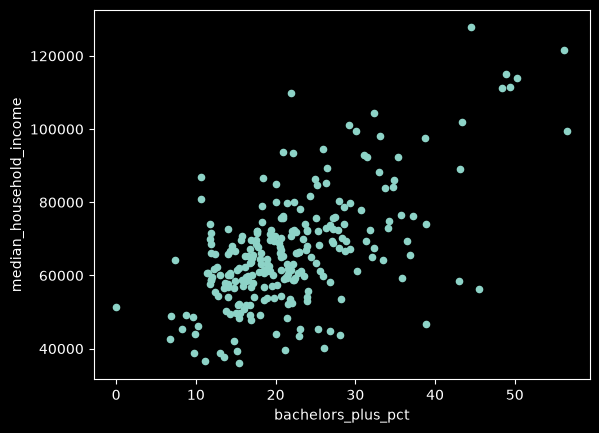

In [7]:
df.plot.scatter(
    x="bachelors_plus_pct",
    y="median_household_income"
)

## Housing Affordability

In [8]:
df[
    [
        "NAME",
        "median_household_income",
        "median_home_value",
        "median_household_income"
    ]
]

,NAME,median_household_income,median_home_value,median_household_income
0,"Anderson County, Texas",62068,185300,62068
1,"Andrews County, Texas",72242,195700,72242
2,"Angelina County, Texas",60960,163500,60960
3,"Aransas County, Texas",69466,265400,69466
4,"Archer County, Texas",72159,189100,72159
...,...,...,...,...
249,"Wood County, Texas",60300,216500,60300
250,"Yoakum County, Texas",84925,182600,84925
251,"Young County, Texas",68010,175800,68010
252,"Zapata County, Texas",39239,97100,39239
